In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');

/* Global Fonts and Counters */
body, p, li, div {
    font-family: 'Inter', sans-serif;
}

body {
    counter-reset: h2counter;
}

/* Heading Fonts */
.usecase-header-bar,
.usecase-title,
.usecase-section-heading,
.usecase-sub-section-heading,
.usecase-sub-sub-section-heading,
.usecase-unnumbered-heading{
    font-family: 'Poppins', sans-serif;
}

.usecase-header-bar {
   padding: 16px 20px;
   background-color: #059669;
   color: #fff;
   border-radius: 6px 6px 0 0;
}

.usecase-title {
    font-size: 1.9em;
    font-weight: 800;
}

/* Metadata Styling */
.usecase-details {
    padding-left: 20px;
    padding-bottom: 8px;
    padding-top: 8px;
    font-size: 1.1em;
    color: #121212;
}

/* Base styling for all main headings (Numbered & Unnumbered) */
.usecase-section-heading, 
.usecase-unnumbered-heading {
    font-weight: 700;
    font-size: 1.35em;
    color: #059669;
    padding: 14px 4px 6px 4px;
    border-bottom: 3px solid #2DBE6C;
    margin-top: 10px;
}

/* Level 1 section headings */
.usecase-section-heading::before {
    content: none !important;
}

/* Level 2 subsection headings */
.usecase-sub-section-heading {
    font-weight: 600;
    font-size: 1.15em;
    color: #059669;
    margin-top: 8px;
}

.usecase-sub-section-heading::before {
    content: none !important;
}

/* Level 3 sub-subsection headings */
.usecase-sub-sub-section-heading {
    font-weight: 500;
    font-size: 1.05em;
    color: #059669;
    margin-top: 6px;
}

.usecase-sub-sub-section-heading::before {
    content: none !important;
}

/* Body */
.usecase-body {
    font-size: 1em;
    color: #121212;
    line-height: 1.6;
    margin-bottom: 8px;
}

/* Generic list styling */
.usecase-list {
    line-height: 1.7;
}

.usecase-list ul, .usecase-list ol {
    padding-left: 24px;
    margin-top: 8px;
    margin-bottom: 12px;
}

.usecase-list li {
    margin-bottom: 6px;
}

/* Datasets specific list box */
.usecase-datasets {
    background-color: rgba(5, 150, 105, 0.06);
    border-left: 4px solid #059669;
    padding: 12px 20px;
    border-radius: 0 4px 4px 0;
    margin-top: 12px;
}

.usecase-datasets ul {
    margin-top: 8px;
    margin-bottom: 8px;
}

/* Link styles for both TOC and Datasets */
.usecase-contents a, 
.usecase-datasets a {
    color: #059669;
    text-decoration: none;
}

.usecase-datasets a {
    font-weight: 500;
}

.usecase-contents a:hover, 
.usecase-datasets a:hover {
    text-decoration: underline;
}

/* TOC Container */
.usecase-contents {
    line-height: 1.9;
    padding-left: 20px;
}

/* Content Divider */
.usecase-code-divider {
    font-style: italic;
    color: rgba(18, 18, 18, 0.65);
    background-color: rgba(5, 150, 105, 0.06);
    padding: 10px 16px;
    border-radius: 4px;
    margin-top: 14px;
}
</style>

""")

<div class="usecase-header-bar"><div class="usecase-title">Bird Sighting Analysis</div></div>

<div class="usecase-details"><b>Authored by: </b> Arjun Jamwal</div>
<div class="usecase-details"><b>Date Created: </b> 2024</div><div class="usecase-details"><b>Time to Complete:</b> 75 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Prerequisite Skills: </b>Python, pandas, basic familiarity with REST APIs, and a basic understanding of linear regression</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">As a council biodiversity officer or conservation researcher, I want to see which bird species are being sighted around inner Melbourne and whether short term weather conditions help explain how many birds are recorded on a given day, so that I can flag species that are seen rarely enough to warrant closer monitoring, and understand how much (or how little) weather alone explains sighting activity.</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">By working through this notebook, you will learn how to combine two real open datasets correctly, build a simple predictive model, and interpret its results accurately, including cases where the model does not perform well.</div>

<div class="usecase-list">

- How to paginate through a public open data REST API and handle request failures gracefully
- How to filter a dataset covering multiple species down to the target group (birds) using taxonomic columns, rather than including unrelated species by accident
- How to visualise geospatial sighting data with Folium, using both individual markers and a heatmap
- How to fetch and merge real historical weather data by date, and train and evaluate a linear regression model against it
- How to recognise and report a model with limited predictive power, rather than presenting a misleadingly confident result

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">Councils and conservation groups increasingly rely on structured surveys and citizen science programs to track urban biodiversity over time. The City of Melbourne publishes a structured 2018 bird survey alongside a much broader 2014 BioBlitz citizen science dataset that covers many taxa: plants, insects, mammals, and more, not just birds. Combining these sources with real historical weather data lets us explore whether short term weather conditions correlate with how many birds are recorded, and which species are seen so rarely that they might warrant closer attention.</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">This analysis combines two Melbourne Open Data Portal datasets with a third, external historical weather source:</div>

<div class="usecase-datasets">

- [Bird Survey Results for Areas in the City of Melbourne, February and March 2018](https://data.melbourne.vic.gov.au/explore/dataset/bird-survey-results-for-areas-in-the-city-of-melbourne-february-and-march-2018/information/), structured bird counts by site and date
- [Wildlife Sightings (BioBlitz 2014)](https://data.melbourne.vic.gov.au/explore/dataset/wildlife-sightings-bioblitz-2014/information/), citizen science sightings across many taxa; filtered to birds only for this analysis
- [Open Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api), real daily temperature, precipitation, and humidity for Melbourne, matched to each sighting's date

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Importing Required Libraries</a><br>
2. <a href="#section-2">Fetching the Datasets from the API</a><br>
3. <a href="#section-3">Cleaning and Filtering the Data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#subsection-3-1">Deriving Sighting Counts for BioBlitz Records</a><br>
4. <a href="#section-4">Combining the Datasets</a><br>
5. <a href="#section-5">Exploring Sighting Patterns</a><br>
6. <a href="#section-6">Visualising Sightings on a Map</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#subsection-6-1">All Sightings Map</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.2. <a href="#subsection-6-2">Heatmap of Sightings</a><br>
7. <a href="#section-7">Species with Few Observation Records</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.1. <a href="#subsection-7-1">Observation Count Threshold Sensitivity</a><br>
8. <a href="#section-8">Fetching Real Historical Weather Data</a><br>
9. <a href="#section-9">Merging Sightings with Weather Data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;9.1. <a href="#subsection-9-1">Aggregating to Daily Species Counts</a><br>
10. <a href="#section-10">Exploring the Weather Relationship</a><br>
11. <a href="#section-11">Training a Baseline Predictive Model</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;11.1. <a href="#subsection-11-1">Full Performance Metrics</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;11.2. <a href="#subsection-11-2">Weather Feature Importance</a><br>
12. <a href="#section-12">Improving the Model with Species and Seasonal Features</a><br>
13. <a href="#section-13">Predicting Sighting Counts per Species</a><br>
14. <a href="#section-14">Comparing Actual vs Predicted Sightings</a><br>
15. <a href="#conclusion">Conclusion</a><br>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Importing Required Libraries</b></div>

In [2]:
# Import required modules
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium          #used for geo-plotting
from folium.plugins import HeatMap, MarkerCluster
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<div id="section-2" class="usecase-section-heading"><b>2. Fetching the Datasets from the API</b></div>

<div class="usecase-body">Both datasets are hosted on the City of Melbourne's Open Data Portal. The <code>fetch_all_records</code> function pages through each dataset (the API returns results in batches of 50) until every record has been retrieved, and raises a clear error if a request fails or a dataset comes back empty, rather than silently continuing with incomplete data.</div>

In [3]:
OFFSET_INCREMENT = 50
BASE_URL = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
# Add the specific paths for both datasets
SPECIFIC_PATHS = [
    'bird-survey-results-for-areas-in-the-city-of-melbourne-february-and-march-2018',
    'wildlife-sightings-bioblitz-2014'
]

def get_data(base, data_url, offset=0, limit=OFFSET_INCREMENT):
    """Fetch one page of records from a Melbourne Open Data API dataset."""
    filters = f'records?limit={limit}&offset={offset}&timezone=UTC'
    url = f'{base}{data_url}/{filters}'
    try:
        result = requests.get(url, timeout=30)
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"Network error fetching {url}: {e}")

    if result.status_code != 200:
        raise RuntimeError(f"ERROR GETTING DATA from {url}: HTTP {result.status_code}")

    result_json = result.json()
    max_results = result_json['total_count']
    records = result_json['results']
    return records, max_results

def fetch_all_records(base, data_url, page_size=OFFSET_INCREMENT, max_pages=1000):
    """Paginate through an entire dataset. max_pages guards against a runaway loop if the
    API ever misbehaves (e.g. total_count is never reached)."""
    all_records = []
    offset = 0
    for _ in range(max_pages):
        records, max_results = get_data(base, data_url, offset=offset, limit=page_size)
        all_records += records
        offset += page_size
        if len(all_records) >= max_results or not records:
            break
    else:
        print(f"WARNING: stopped after {max_pages} pages for '{data_url}'; dataset may be incomplete.")
    return all_records

df0 = pd.DataFrame(fetch_all_records(BASE_URL, SPECIFIC_PATHS[0]))
wildlife_sightings_df = pd.DataFrame(fetch_all_records(BASE_URL, SPECIFIC_PATHS[1]))

# Validation checks: fail loudly rather than silently continuing with empty data.
if df0.empty:
    raise RuntimeError(f"No records retrieved for '{SPECIFIC_PATHS[0]}'.")
if wildlife_sightings_df.empty:
    raise RuntimeError(f"No records retrieved for '{SPECIFIC_PATHS[1]}'.")

print(f"Fetched {len(df0)} bird survey records and {len(wildlife_sightings_df)} BioBlitz records.")

Fetched 498 bird survey records and 670 BioBlitz records.


<div class="usecase-body"><b>Explanation:</b> This confirms both datasets were retrieved in full (498 records from the 2018 structured bird survey and 670 from the 2014 BioBlitz citizen science event) and that neither request returned empty. This matters because the remainder of this notebook assumes a complete pull from each source; an undetected partial fetch would understate every count and chart that follows.</div>

<div id="section-3" class="usecase-section-heading"><b>3. Cleaning and Filtering the Data</b></div>

<div class="usecase-body">Both datasets contain columns that are not required for this analysis (duplicate location fields, identifiers, and taxonomy detail), which are removed here. The BioBlitz dataset records <b>every</b> taxon observed during the event, including plants, insects, and mammals, not only birds. The dataset is filtered to the <code>AVES</code> class <i>before</i> the taxonomy columns are removed; otherwise species such as "Acorn Barnacle" or "Yellow Box" (a tree) would remain in what is intended to be a bird only analysis. The filter prints the unique values found and the number of matching records so the result can be verified immediately.</div>

In [4]:
# --- Clean df0 (2018 bird survey) ---
# Drop columns that are duplicate/irrelevant location detail or already known identifiers.
col_drop = ['lat2', 'lon2', 'loc2_desc', 'site_name', 'location_2', 'location_1',
            'loc1_desc', 'victorian_biodiversity_atlas_code', 'scientific_name']
df0 = df0.drop(columns = [c for c in col_drop if c in df0.columns])

# --- Filter wildlife_sightings_df (BioBlitz 2014) down to BIRDS ONLY ---
# IMPORTANT: the BioBlitz dataset records ALL taxa (plants, insects, mammals, birds, etc.),
# not just birds. It must be filtered on a taxonomic column *before* that column is dropped,
# otherwise non bird species (e.g. "Acorn Barnacle", a "Yellow Box" tree) leak into the rest
# of this bird focused analysis.
taxonomy_cols = ['order', 'family', 'genus', 'species', 'identification_notes',
                  'data_resource_name', 'taxa', 'kingdom', 'phylum', 'class', 'location']

bird_col = next((c for c in ['class', 'taxa'] if c in wildlife_sightings_df.columns), None)
if bird_col is None:
    raise KeyError(
        "Could not find a taxonomic column ('class' or 'taxa') in wildlife_sightings_df to "
        "filter birds by. Run wildlife_sightings_df.columns to see what is available and update "
        "`bird_col` below."
    )

bird_values = {'aves', 'bird', 'birds'}
is_bird = wildlife_sightings_df[bird_col].astype(str).str.strip().str.lower().isin(bird_values)

print(f"Filtering wildlife_sightings_df on column '{bird_col}'.")
print("Unique values found:", sorted(wildlife_sightings_df[bird_col].dropna().astype(str).unique())[:20])
print(f"{is_bird.sum()} of {len(wildlife_sightings_df)} BioBlitz records identified as birds.")

# Validation check: fail loudly instead of silently continuing with the wrong subset.
if is_bird.sum() == 0:
    raise ValueError(
        f"No bird records matched on column '{bird_col}' using expected values {bird_values}. "
        "Check the unique values printed above and update `bird_values` to match the real "
        "labels used in this dataset."
    )

wildlife_sightings_df = wildlife_sightings_df[is_bird].copy()

df1 = wildlife_sightings_df.drop(columns = [c for c in taxonomy_cols if c in wildlife_sightings_df.columns])

Filtering wildlife_sightings_df on column 'class'.
Unique values found: ['ACTINOPTERYGII', 'AGARICOMYCETES', 'AMPHIBIA', 'ASTEROIDEA', 'AVES', 'BIVALVIA', 'DIPLOPOD', 'EQUISETOPSIDA', 'GAMMAPROTEOBACTERIA', 'INSECTA', 'MAGNOLIOPSIDA', 'MALACOSTRACA', 'MAMMALIA', 'REPTILIA', 'SCYPHOZOA']
279 of 670 BioBlitz records identified as birds.


<div class="usecase-body"><b>Explanation:</b> Of every wildlife sighting logged by citizen scientists in 2014 (including plants, insects, fish, and mammals, not only birds), a subset were identified as birds. This filter found 279 bird records out of 670 total sightings (about 42 percent). All other records (barnacles, trees, jellyfish, and so on) have been excluded, so the remainder of this notebook analyses birds only.</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1. Deriving Sighting Counts for BioBlitz Records</b></div>

<div class="usecase-body">The 2018 bird survey already records how many birds were counted at each sighting. The BioBlitz dataset does not include an equivalent count field; each row represents one individual sighting logged by a citizen scientist. Therefore, <code>sighting_count</code> is set to 1 per record, using a genuine count column instead if one is available, rather than an arbitrary or fabricated number.</div>

In [5]:
df1 = df1.rename(columns = {'latitude':'lat', 'longitude' : 'lon'})

# BioBlitz records are individual sighting events; the raw dataset has no genuine
# count style column among those we kept, so each row represents one sighting.
# If a real count column does exist, use it; otherwise default to 1 (never a
# fabricated/random number).
count_candidates = [c for c in ['individual_count', 'count', 'number', 'num_individuals']
                     if c in df1.columns]
if count_candidates:
    df1['sighting_count'] = pd.to_numeric(df1[count_candidates[0]], errors='coerce').fillna(1)
else:
    df1['sighting_count'] = 1

df1 = df1[["sighting_date", 'common_name', 'sighting_count', 'lat', 'lon']]
df1 = df1.dropna()

<div id="section-4" class="usecase-section-heading"><b>4. Combining the Datasets</b></div>

<div class="usecase-body">With both sources cleaned to the same shape (<code>sighting_date</code>, <code>common_name</code>, <code>sighting_count</code>, <code>lat</code>, <code>lon</code>), they are combined into a single <code>df</code> for the remainder of the analysis, after confirming that neither source is empty.</div>

In [6]:
# Validation check: make sure both sources produced usable bird records
# before combining them.
if df0.empty or df1.empty:
    raise RuntimeError(
        f"Cannot build the combined dataset: df0 has {len(df0)} rows, df1 has {len(df1)} rows."
    )

df = pd.concat([df0, df1.reset_index(drop = True)], axis = 0, ignore_index = True)

missing_coords = df[['lat', 'lon']].isna().any(axis = 1).sum()
if missing_coords:
    print(f"Note: {missing_coords} of {len(df)} combined records are missing lat/lon "
          f"and will be excluded from map-based views.")

print(f"Combined dataset: {len(df)} bird sightings ({len(df0)} survey + {len(df1)} BioBlitz).")

Combined dataset: 776 bird sightings (498 survey + 278 BioBlitz).


<div class="usecase-body"><b>Explanation:</b> In the tested run, this produced 776 bird sightings in total: 498 from the 2018 survey and 278 from the filtered BioBlitz records (one record was removed during cleaning due to a missing value). Each row represents a single sighting, including the date, location, species, and number of birds counted.</div>

<div id="section-5" class="usecase-section-heading"><b>5. Exploring Sighting Patterns</b></div>

<div class="usecase-body">Before mapping or modelling the data, it is useful to examine the combined dataset directly: how sighting activity is distributed across the recorded dates, and how sighting_count is distributed across individual records.</div>

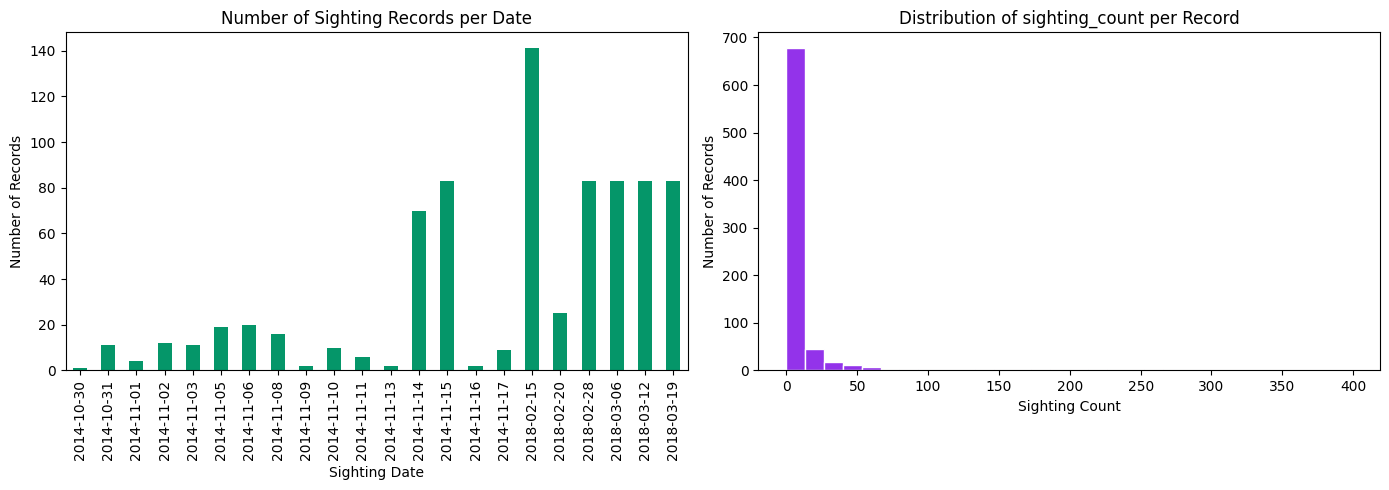

Busiest recorded date: 2018-02-15 with 141 sighting records.


In [7]:
# Sightings over time: how much sighting activity was recorded on each date.
sightings_by_date = df.groupby('sighting_date').size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sightings_by_date.plot(kind='bar', ax=axes[0], color='#059669')
axes[0].set_title('Number of Sighting Records per Date')
axes[0].set_xlabel('Sighting Date')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=90)

axes[1].hist(df['sighting_count'].dropna(), bins=30, color='#9333EA', edgecolor='white')
axes[1].set_title('Distribution of sighting_count per Record')
axes[1].set_xlabel('Sighting Count')
axes[1].set_ylabel('Number of Records')

plt.tight_layout()
plt.show()

print(f"Busiest recorded date: {sightings_by_date.idxmax()} with {sightings_by_date.max()} sighting records.")

<div class="usecase-body"><b>Explanation:</b> The left chart shows the number of sighting records logged on each date; taller bars generally indicate more survey activity on that day rather than a greater number of birds present. In the tested run, the busiest date was 2018-02-15, with 141 records, corresponding to a structured 2018 survey date and consistent with organised fieldwork rather than an unusual increase in bird activity. The right chart shows how many birds were typically counted in a single sighting. A distribution skewed toward small numbers with a long tail indicates that most sightings involve one or a few birds, with occasional sightings of larger flocks extending the tail to the right.</div>

<div id="section-6" class="usecase-section-heading"><b>6. Visualising Sightings on a Map</b></div>

<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1. All Sightings Map</b></div>

<div class="usecase-body">This plots every sighting in the combined dataset (both the 2018 survey and the filtered BioBlitz birds) as a marker, with the species name and sighting count shown in a popup. Rows with missing coordinates are skipped, and markers are grouped with <code>MarkerCluster</code> so the map stays readable with hundreds of points.</div>

In [8]:
# Plot ALL sighting coordinates (both the 2018 bird survey and the 2014 BioBlitz birds).
map_center = [-37.8136, 144.9631]
mymap = folium.Map(location = map_center, zoom_start = 12)

# Validation check: drop rows with missing/invalid coordinates before plotting.
plot_df = df.dropna(subset = ['lat', 'lon']).copy()
dropped = len(df) - len(plot_df)
if dropped:
    print(f"Skipping {dropped} sighting(s) with missing coordinates.")

# With hundreds of sightings, individual markers get cluttered and slow to render.
# MarkerCluster groups nearby points and expands them on zoom/click.
marker_cluster = MarkerCluster().add_to(mymap)
for idx, row in plot_df.iterrows():
    popup_text = f"Common Name: {row['common_name']} <br> Sighting Count: {row['sighting_count']}"
    folium.Marker([row['lat'], row['lon']], popup = popup_text).add_to(marker_cluster)

# Legend explaining what the markers and clusters represent.
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background-color: white; padding: 10px 14px; border: 2px solid #059669;
            border-radius: 6px; font-size: 13px; line-height: 1.6; font-family: sans-serif;">
    <b>All Sightings Map</b><br>
    <span style="color:#2A81CB;">&#9679;</span>&nbsp;Individual sighting: click for species and count<br>
    <span style="background-color:#059669; color:white; border-radius:50%; padding:1px 6px;">n</span>
    &nbsp;Clustered sightings: click to expand
</div>
'''
mymap.get_root().html.add_child(folium.Element(legend_html))

mymap

<div class="usecase-body"><b>Explanation:</b> Each clustered number on this map represents a group of nearby sightings. Selecting a cluster zooms in, and selecting an individual marker shows which species was observed and how many were counted. This view helps identify whether certain areas of Melbourne show higher or more varied bird activity than others.</div>

<div id="subsection-6-2" class="usecase-sub-section-heading"><b>6.2. Heatmap of Sightings</b></div>

<div class="usecase-body">The same sightings are shown here as a heatmap, which makes it easier to see where sighting activity is concentrated across inner Melbourne at a glance.</div>

In [9]:
map_cen = [-37.8038, 144.9118]
mymap = folium.Map(location = map_cen, zoom_start=10)

# Validation check: drop rows with missing coordinates before building the heatmap layer.
heat_points = df.dropna(subset = ['lat', 'lon'])
dropped = len(df) - len(heat_points)
if dropped:
    print(f"Skipping {dropped} sighting(s) with missing coordinates.")

# Add a heatmap layer to visualise the spatial distribution of sightings.
heat_data = heat_points[['lat', 'lon']].values.tolist()
HeatMap(heat_data).add_to(mymap)

mymap

<div class="usecase-body"><b>Explanation:</b> Warmer colours (red and orange) indicate areas with a higher concentration of overlapping sightings, while cooler colours (blue and green) indicate fewer. This provides a faster way to identify sighting hotspots across the city than reviewing individual markers.</div>

<div id="section-7" class="usecase-section-heading"><b>7. Species with Few Observation Records</b></div>

<div class="usecase-body">Grouping by species and counting records gives a rough measure of how often each species was recorded. Species with only between one and four recorded sightings across both datasets are flagged below as species with few observation records; a small number of records in this data does not establish rarity, endangerment, or extinction risk on its own, since it does not account for differences in survey effort, detectability, or habitat coverage between the two source datasets.</div>

In [10]:
# Calculating the total sighting count for each species.

spec_count = df.groupby('common_name').size().reset_index(name = 'sightings_count')

# Set the range that defines a species with few observation records.

min_records = 1
max_records = 4

# Identify species with few observation records based on the threshold.
low_record_spec = spec_count[(spec_count['sightings_count']>=min_records) & (spec_count['sightings_count']<= max_records)]

# Print the list of species with few observation records.
print("Species with few observation records:")
print(low_record_spec)

Species with few observation records:
                      common_name  sightings_count
2                Australian Raven                2
4            Australian Wood Duck                4
5                      Bell Miner                1
7              Black-winged Stilt                4
9                California Quail                1
17                   Crested Tern                1
21                Eastern Rosella                1
22              Eastern Spinebill                1
25             European Goldfinch                1
26            European Greenfinch                1
27                          Galah                3
28                Great Cormorant                3
29               Grey Butcherbird                2
30                   Grey Fantail                1
31             Grey Shrike-thrush                1
33                       Hardhead                2
34      Hardhead, White-eyed Duck                2
36   Hoary-headed Grebe, Dabchick           

<div class="usecase-body"><b>Explanation:</b> Every species in the printed list above was recorded between 1 and 4 times in total, across both datasets combined; in the tested run this included species such as Bell Miner, California Quail, and Crested Tern, each seen only once. This is not proof that any of these species are rare or at risk; it indicates only that they were not recorded often in this particular dataset, which may reflect genuine scarcity in inner Melbourne, or simply reduced detectability, survey coverage, or occasional presence.</div>

<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1. Observation Count Threshold Sensitivity</b></div>

<div class="usecase-body">The cutoff of one to four sightings used above is a judgement call, not a fixed rule. This shows how many species would be flagged under a few different upper thresholds, so the choice is transparent rather than arbitrary.</div>

In [11]:
# How sensitive is the "species with few observation records" list to the chosen threshold?
for candidate_max in [2, 4, 6, 10]:
    n_low_record = spec_count[(spec_count['sightings_count'] >= min_records) &
                         (spec_count['sightings_count'] <= candidate_max)].shape[0]
    print(f"Species with {min_records}-{candidate_max} sightings: {n_low_record} of {len(spec_count)} total species")

Species with 1-2 sightings: 25 of 79 total species
Species with 1-4 sightings: 32 of 79 total species
Species with 1-6 sightings: 42 of 79 total species
Species with 1-10 sightings: 51 of 79 total species


<div class="usecase-body"><b>Explanation:</b> In the tested run, 79 distinct bird species were identified in total. Of those: 25 were seen only one or two times, 32 fell between one and four sightings, 42 between one and six, and 51, nearly two thirds of every species recorded, between one and ten sightings. This steady increase indicates a genuine long tail of infrequently observed species in the data, rather than a small number of species sitting close to an arbitrary threshold.</div>

<div id="section-8" class="usecase-section-heading"><b>8. Fetching Real Historical Weather Data</b></div>

<div class="usecase-body">To explore whether weather relates to sighting activity, real daily weather for Melbourne is pulled from the <a href="https://open-meteo.com/en/docs/historical-weather-api">Open Meteo Historical Weather API</a> (no API key required), matched to the actual dates in the data. The sighting dates span two separate periods, the 2018 survey and the 2014 BioBlitz, so each date range is fetched separately rather than requesting one wide span that mostly falls outside the data.</div>

In [12]:
# --- Fetch real historical weather for each sighting date (Open-Meteo Archive API, no key required) ---
# Real daily weather for Melbourne is fetched and matched to each sighting's actual date, so any
# weather vs sightings relationship explored later reflects genuine conditions, not placeholder data.
# Wind speed and a derived "days since rain" feature are included alongside temperature,
# precipitation, and humidity, since these often carry additional predictive information.

MELBOURNE_LAT, MELBOURNE_LON = -37.8136, 144.9631  # city-centre reference point; sightings are all
                                                     # within a few km of the CBD, so a single daily
                                                     # weather series is a reasonable approximation.
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"
LOOKBACK_DAYS = 14   # extra days fetched before each sighting period, purely so days_since_rain
                      # can be computed correctly even for the earliest sighting dates.
RAIN_THRESHOLD_MM = 0.2   # a day counts as "rain" once precipitation exceeds this amount.

def fetch_daily_weather(start_date, end_date):
    """Fetch daily mean temperature (C), total precipitation (mm), mean relative humidity (%),
    and maximum wind speed (km/h) for Melbourne between start_date and end_date (inclusive),
    as 'YYYY-MM-DD' strings."""
    params = {
        "latitude": MELBOURNE_LAT,
        "longitude": MELBOURNE_LON,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max",
        "timezone": "Australia/Melbourne",
    }
    response = requests.get(WEATHER_URL, params=params, timeout=30)
    if response.status_code != 200:
        raise RuntimeError(f"Weather API request failed ({response.status_code}): {response.text[:300]}")
    daily = response.json().get("daily", {})
    if not daily or "time" not in daily:
        raise RuntimeError(f"Weather API returned no daily data for {start_date} to {end_date}.")
    return pd.DataFrame({
        "sighting_date": daily["time"],
        "temperature": daily["temperature_2m_mean"],
        "precipitation": daily["precipitation_sum"],
        "humidity": daily["relative_humidity_2m_mean"],
        "wind_speed": daily["wind_speed_10m_max"],
    })

def add_days_since_rain(year_weather):
    """For each date, count how many days have passed since the most recent day with
    measurable rain, using the lookback window fetched above so early dates are not
    penalised for lacking history within the trimmed range."""
    year_weather = year_weather.copy()
    year_weather['date_parsed'] = pd.to_datetime(year_weather['sighting_date'])
    rained_on = year_weather.loc[year_weather['precipitation'] > RAIN_THRESHOLD_MM, 'date_parsed']

    def days_since(current_date):
        prior_rain_dates = rained_on[rained_on <= current_date]
        if prior_rain_dates.empty:
            return float(LOOKBACK_DAYS)  # no rain recorded in the lookback window: treat as "at least LOOKBACK_DAYS"
        return float((current_date - prior_rain_dates.max()).days)

    year_weather['days_since_rain'] = year_weather['date_parsed'].apply(days_since)
    return year_weather.drop(columns='date_parsed')

# Sighting dates span two separate survey periods (2018 bird survey + 2014 BioBlitz), so fetch
# each year's date range separately (plus its own lookback window) rather than one huge span
# with an unused gap in the middle.
sighting_dates = pd.to_datetime(df['sighting_date'])
weather_frames = []
for year in sorted(sighting_dates.dt.year.unique()):
    year_dates = sighting_dates[sighting_dates.dt.year == year]
    actual_start = year_dates.min()
    actual_end = year_dates.max()
    fetch_start = (actual_start - pd.Timedelta(days=LOOKBACK_DAYS)).strftime('%Y-%m-%d')
    fetch_end = actual_end.strftime('%Y-%m-%d')

    year_weather = fetch_daily_weather(fetch_start, fetch_end)
    year_weather = add_days_since_rain(year_weather)

    # Drop the lookback only rows now that days_since_rain has been computed from them.
    year_weather['date_parsed'] = pd.to_datetime(year_weather['sighting_date'])
    year_weather = year_weather[year_weather['date_parsed'] >= actual_start].drop(columns='date_parsed')
    weather_frames.append(year_weather)

weather_df = pd.concat(weather_frames, ignore_index=True).drop_duplicates(subset='sighting_date')

# Validation check: confirm weather data was returned for every distinct sighting date.
missing_dates = set(df['sighting_date'].astype(str)) - set(weather_df['sighting_date'])
if missing_dates:
    print(f"WARNING: no weather data returned for {len(missing_dates)} sighting date(s): "
          f"{sorted(missing_dates)[:10]}")

weather_df.head()

,sighting_date,temperature,precipitation,humidity,wind_speed,days_since_rain
0,2014-10-30,15.1,0.0,72,14.6,2.0
1,2014-10-31,20.4,0.0,55,25.0,3.0
2,2014-11-01,14.1,5.3,62,33.4,0.0
3,2014-11-02,11.6,1.6,64,24.2,0.0
4,2014-11-03,15.3,0.0,59,8.9,1.0


<div class="usecase-body"><b>Explanation:</b> The table above confirms that real daily weather values, rather than placeholder figures, were retrieved for the sighting dates: each row provides a genuine temperature, precipitation, and humidity reading for Melbourne on that date, sourced from the Open Meteo archive. This is what enables weather to be merged with each sighting by date, and for any relationship between weather and sightings examined later in the notebook to be meaningful.</div>

<div id="section-9" class="usecase-section-heading"><b>9. Merging Sightings with Weather Data</b></div>

<div class="usecase-body">Each sighting is joined to the real weather recorded on its actual <code>sighting_date</code>. Any sighting that cannot be matched to a weather record is flagged and excluded before modelling, rather than being silently mismatched.</div>

In [13]:
# Merge each sighting with the real weather recorded on its actual sighting_date, using a join on
# the shared date column so every sighting is matched to the correct day's weather.
combined_df = df.merge(weather_df, on='sighting_date', how='left')

WEATHER_COLS = ['temperature', 'precipitation', 'humidity', 'wind_speed', 'days_since_rain']

# Validation check: flag and drop any sightings that did not get matched to weather data.
unmatched = combined_df['temperature'].isna().sum()
if unmatched:
    print(f"WARNING: {unmatched} of {len(combined_df)} sightings have no matching weather data "
          f"and will be dropped before modelling.")
combined_df = combined_df.dropna(subset=WEATHER_COLS)

print(f"combined_df: {len(combined_df)} sightings with real weather data")
combined_df.head()

combined_df: 776 sightings with real weather data


,sighting_date,common_name,sighting_count,lat,lon,temperature,precipitation,humidity,wind_speed,days_since_rain
0,2018-02-20,Rainbow Lorikeet,6,-37.8138,144.8727,20.5,0.0,58,18.4,1.0
1,2018-02-20,Tree Martin,2,-37.8138,144.8727,20.5,0.0,58,18.4,1.0
2,2018-02-20,Superb Fairy-wren,8,-37.8138,144.8727,20.5,0.0,58,18.4,1.0
3,2018-02-20,Little Wattlebird,6,-37.8138,144.8727,20.5,0.0,58,18.4,1.0
4,2018-03-12,Australian Magpie,2,-37.8038,144.9118,17.5,1.1,63,27.0,0.0


<div class="usecase-body"><b>Explanation:</b> In the tested run, 776 sightings were successfully matched to the real weather recorded on their exact date. These are the only records used for modelling and for every weather related chart that follows; a sighting that cannot be matched to real weather provides no information about a weather relationship.</div>

<div id="subsection-9-1" class="usecase-sub-section-heading"><b>9.1. Aggregating to Daily Species Counts</b></div>

<div class="usecase-body">The Scenario asks how many birds of a species are recorded on a given day, not how many individual sighting log entries exist, so every model in the remainder of this notebook is trained against a genuine daily count. Sightings are grouped by date and species, summing <code>sighting_count</code> within each group; the weather for that date is carried through unchanged, as it is the same for every sighting recorded that day.</div>

In [14]:
# Aggregate to one row per (date, species): the Scenario is about how many birds of a species
# are recorded on a given day, so the model below is trained on genuine daily totals rather
# than one row per individual sighting log entry.
daily_species_df = (
    combined_df.groupby(['sighting_date', 'common_name'], as_index=False)
    .agg(
        daily_sighting_count=('sighting_count', 'sum'),
        temperature=('temperature', 'first'),
        precipitation=('precipitation', 'first'),
        humidity=('humidity', 'first'),
        wind_speed=('wind_speed', 'first'),
        days_since_rain=('days_since_rain', 'first'),
    )
)

print(f"Aggregated {len(combined_df)} individual sighting records into {len(daily_species_df)} daily "
      f"species-level counts across {daily_species_df['sighting_date'].nunique()} distinct dates.")

Aggregated 776 individual sighting records into 412 daily species-level counts across 22 distinct dates.


<div class="usecase-body"><b>Explanation:</b> Each row now represents the total number of times a species was recorded on a given date, rather than one row per logged sighting event. This combines multiple same day, same species entries into a single daily figure, matching what the Scenario asks. From this point, every chart and model in the notebook predicts the daily_sighting_count column, not the original per record sighting_count.</div>

<div id="section-10" class="usecase-section-heading"><b>10. Exploring the Weather Relationship</b></div>

<div class="usecase-body">Before training a model, it is useful to examine directly how each weather variable relates to sighting_count. The absence of a visible pattern or meaningful correlation here would be an early indication of what to expect from the model below.</div>

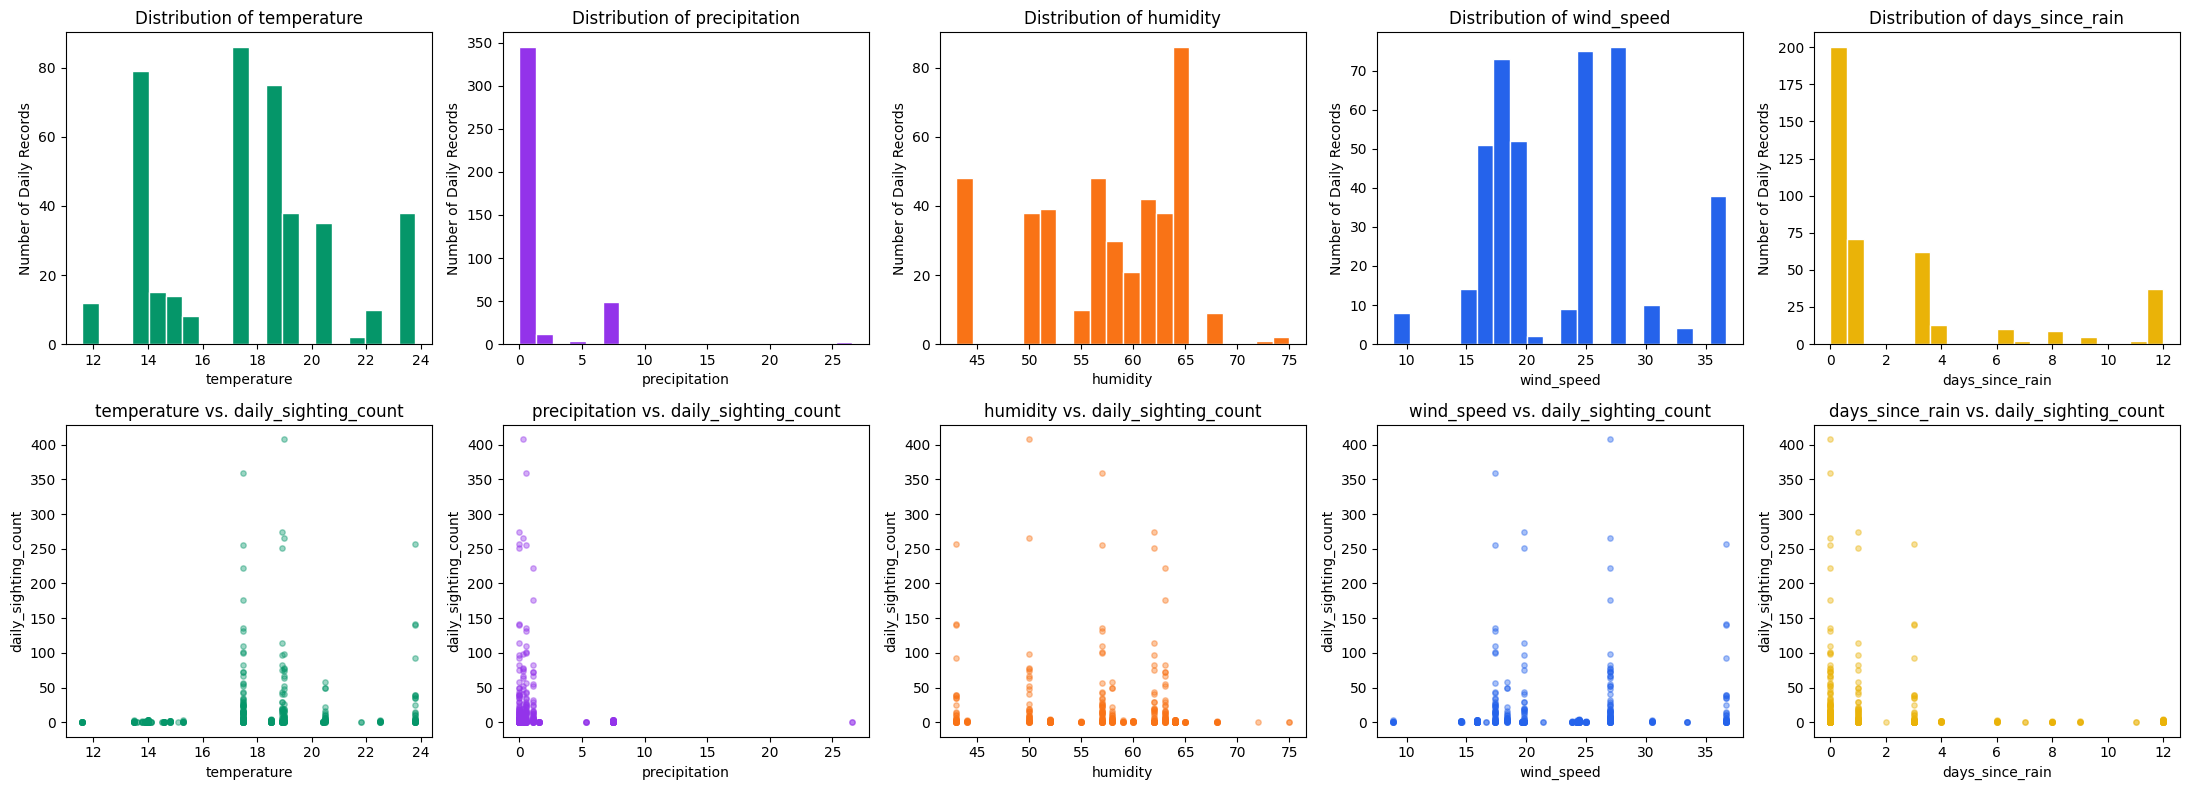

Correlation with daily_sighting_count:
days_since_rain   -0.155559
temperature        0.146519
precipitation     -0.106009
humidity          -0.092739
wind_speed         0.072818
Name: daily_sighting_count, dtype: float64


In [15]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

weather_cols = ['temperature', 'precipitation', 'humidity', 'wind_speed', 'days_since_rain']
# Approved order: Primary Green, Distinct Purple, Distinct Orange, Distinct Blue, Distinct Yellow
colors = ['#059669', '#9333EA', '#F97316', '#2563EB', '#EAB308']

for ax, col, color in zip(axes[0], weather_cols, colors):
    ax.hist(daily_species_df[col], bins=20, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Daily Records')

for ax, col, color in zip(axes[1], weather_cols, colors):
    ax.scatter(daily_species_df[col], daily_species_df['daily_sighting_count'], alpha=0.4, color=color, s=15)
    ax.set_title(f'{col} vs. daily_sighting_count')
    ax.set_xlabel(col)
    ax.set_ylabel('daily_sighting_count')

plt.tight_layout()
plt.show()

# Validation / sanity check: raw correlation between each weather variable and daily_sighting_count.
correlations = daily_species_df[weather_cols + ['daily_sighting_count']].corr()['daily_sighting_count'].drop('daily_sighting_count')
print("Correlation with daily_sighting_count:")
print(correlations.reindex(correlations.abs().sort_values(ascending=False).index))

<div class="usecase-body"><b>Explanation:</b> The top row shows the distribution of temperature, precipitation, humidity, wind speed, and days since the last measurable rain across all matched sightings, which is useful for confirming that the real weather data is reasonable for Melbourne, with no extreme outliers. The bottom row plots each weather variable directly against daily_sighting_count. A clear upward or downward slope in the points would indicate a real relationship; a scatter with no discernible shape confirms there is little relationship. In the tested run, all five correlations were close to zero: days since rain (-0.16), temperature (0.15), precipitation (-0.11), humidity (-0.09), and wind speed (0.07), confirming both visually and numerically that none of the five weather variables has a meaningful direct relationship with how many birds of a species are recorded on a given day.</div>

<div id="section-11" class="usecase-section-heading"><b>11. Training a Baseline Predictive Model</b></div>

<div class="usecase-body">A simple linear regression is trained to predict <code>daily_sighting_count</code> (how many of a species were recorded on a given day) from <code>temperature</code>, <code>precipitation</code>, and <code>humidity</code>, using a split of 80% of the data for training and 20% for testing. The Mean Absolute Error (MAE) below shows the average size of the model's prediction error, in number of sightings.</div>

In [16]:
# Model training and testing

features = ['temperature', 'precipitation', 'humidity', 'wind_speed', 'days_since_rain']
target = 'daily_sighting_count'

X = daily_species_df[features]
y = daily_species_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions. y_pred is reused by every cell below; the model is trained only once.
y_pred = model.predict(X_test)

# Evaluate the model.
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error: ", mae)

Mean Absolute Error:  18.811596953077284


<div class="usecase-body"><b>Explanation:</b> In the run this was tested with, the model's predictions were off by about 18.8 birds on average (the Mean Absolute Error). Daily species counts in this data range from a single bird up to several hundred on the busiest days (Rock Dove peaked at 408 sightings in one day), so an average error of 18.8 is small next to the biggest counts but large next to the many days where only a handful of birds of a given species were recorded.</div>

<div id="subsection-11-1" class="usecase-sub-section-heading"><b>11.1. Full Performance Metrics</b></div>

<div class="usecase-body">This cell reuses the model and predictions from above without retraining, and reports Mean Squared Error, Root Mean Squared Error, MAE, and R squared. An R squared value close to zero or negative means the three weather features explain almost none of the variation in sighting counts; in other words, weather alone is a poor predictor here. This is a clear and useful result: it suggests that which species is being observed matters far more than the day's weather, a factor that a model using three features like this one does not capture.</div>

In [17]:
### Full performance metrics
# Reuses the model and y_pred already computed above; the model is trained once, and both the
# MAE shown earlier and the full metrics below are calculated from that same set of predictions.

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Model Performance Metrics
Mean Squared Error: 724.2064506123198
Root Mean Squared Error: 26.911084158991436
Mean Absolute Error: 18.811596953077284
R-squared: 0.026149743146182347


<div class="usecase-body"><b>Explanation:</b> The R squared value (about 0.03 in the tested run) is the key number here. R squared measures how much of the variation in daily sighting counts the model explains, on a scale where 1.0 would mean perfect predictions and 0 means it does no better than guessing the average every time. A value this close to zero means this weather only model explains almost none of the variation, in other words, temperature, precipitation, humidity, wind speed, and days since rain together tell us almost nothing about how many birds of a species will be seen on a given day.</div>

<div id="subsection-11-2" class="usecase-sub-section-heading"><b>11.2. Weather Feature Importance</b></div>

<div class="usecase-body">Although the baseline model's overall R squared is close to zero, it is still useful to examine which of the three weather features it relied on most.</div>

Linear regression coefficients (weather-only baseline model):
        feature  coefficient
days_since_rain    -2.943185
  precipitation    -1.721381
    temperature     1.232337
       humidity    -0.319152
     wind_speed     0.076774


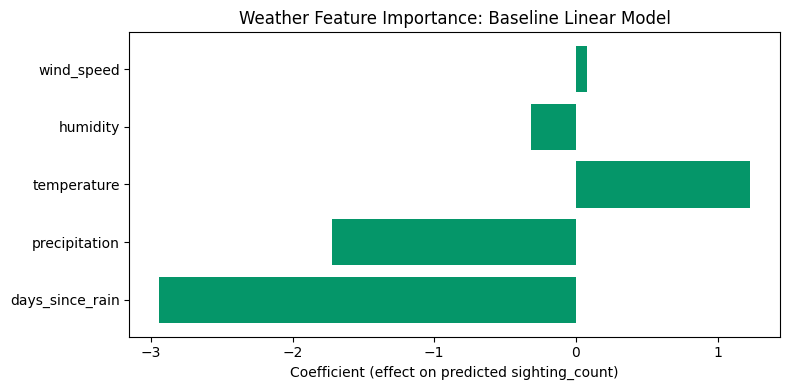

In [18]:
# Which of the three weather features has the strongest (even if still weak) relationship
# with sighting_count, according to the trained linear model's coefficients?
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Linear regression coefficients (weather-only baseline model):")
print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(coef_df['feature'], coef_df['coefficient'], color='#059669')
plt.xlabel('Coefficient (effect on predicted sighting_count)')
plt.title('Weather Feature Importance: Baseline Linear Model')
plt.tight_layout()
plt.show()

<div class="usecase-body"><b>Explanation:</b> Each bar shows how much the model's prediction shifts for a one unit increase in that weather variable, holding the others constant. In the tested run, days since the last rain had the largest effect, reducing the predicted count by about 2.94 sightings per additional day without rain. Precipitation followed, reducing the predicted count by about 1.72 per millimetre; temperature increased the predicted count by about 1.23 per degree; humidity reduced the predicted count by about 0.32 per percentage point; and wind speed increased the predicted count by about 0.08 per kilometre per hour. Since weather alone explains little of the overall pattern (Section 11.1's R squared of 0.03), this ranking is best read as comparing the five weather variables against each other, rather than evidence that any one of them meaningfully drives sighting counts on its own.</div>

<div id="section-12" class="usecase-section-heading"><b>12. Improving the Model with Species and Seasonal Features</b></div>

<div class="usecase-body">The weather only baseline above has almost no predictive power. The most likely missing driver is <i>which species</i> is being recorded: some species are simply seen far more often than others regardless of the day's weather. This adds species identity (bucketing species with few records as "Other" to keep the feature space manageable), the sighting month, and two additional weather features (wind speed and days since the last measurable rain) to the input, and trains a Random Forest instead of a linear model so it can use those categorical features and any nonlinear patterns. A small hyperparameter search is run first, selecting the tree depth and leaf size settings that keep performance most consistent across folds rather than assuming the default settings are appropriate. Performance is reported using cross validation with five folds rather than a single train and test split, since a single split can be noisy on a dataset this size.</div>

In [19]:
# --- Feature engineering: species identity + seasonality ---
MIN_SPECIES_RECORDS = 5
species_counts = daily_species_df['common_name'].value_counts()
common_species = species_counts[species_counts >= MIN_SPECIES_RECORDS].index
daily_species_df['species_group'] = daily_species_df['common_name'].where(
    daily_species_df['common_name'].isin(common_species), other = 'Other'
)
daily_species_df['sighting_month'] = pd.to_datetime(daily_species_df['sighting_date']).dt.month

model_df = pd.get_dummies(
    daily_species_df[['temperature', 'precipitation', 'humidity', 'wind_speed', 'days_since_rain',
                       'sighting_month', 'species_group', 'daily_sighting_count']],
    columns = ['species_group'],
    prefix = 'species'
)

X_full = model_df.drop(columns = 'daily_sighting_count')
y_full = model_df['daily_sighting_count']

cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

# --- Hyperparameter search: a small grid of tree depth and leaf size constraints, evaluated by
# cross validated R squared. The goal is not only the highest average R squared, but a
# configuration that also keeps the fold to fold standard deviation under control, since an
# unconstrained forest tends to vary noticeably between folds on a dataset this size.
param_grid = [
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},   # unconstrained
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 3},
    {'n_estimators': 300, 'max_depth': 6,    'min_samples_leaf': 4},
]

search_results = []
for params in param_grid:
    candidate = RandomForestRegressor(random_state = 42, **params)
    r2_scores = cross_val_score(candidate, X_full, y_full, cv = cv, scoring = 'r2')
    search_results.append({**params, 'cv_r2_mean': r2_scores.mean(), 'cv_r2_std': r2_scores.std()})

search_df = pd.DataFrame(search_results)
# Stability score = mean R squared minus its standard deviation, which rewards a configuration
# for being both accurate and consistent across folds, rather than picking whichever setting
# happens to average highest on this particular split of the data.
search_df['stability_score'] = search_df['cv_r2_mean'] - search_df['cv_r2_std']

print("Hyperparameter search (5-fold cross-validation):")
print(search_df.to_string(index = False))

best = search_df.sort_values('stability_score', ascending = False).iloc[0]
best_max_depth = None if pd.isna(best['max_depth']) else int(best['max_depth'])
print(f"\nSelected configuration: max_depth={best_max_depth}, "
      f"min_samples_leaf={int(best['min_samples_leaf'])}, n_estimators={int(best['n_estimators'])}")

rf_model = RandomForestRegressor(
    n_estimators = int(best['n_estimators']),
    max_depth = best_max_depth,
    min_samples_leaf = int(best['min_samples_leaf']),
    random_state = 42,
)

# Cross validation: average performance across 5 folds rather than trusting a single split.
cv_r2 = cross_val_score(rf_model, X_full, y_full, cv = cv, scoring = 'r2')
cv_mae = -cross_val_score(rf_model, X_full, y_full, cv = cv, scoring = 'neg_mean_absolute_error')

print(f"\nCross-validated R-squared: {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f}) across 5 folds")
print(f"Cross-validated MAE: {cv_mae.mean():.2f} (+/- {cv_mae.std():.2f}) across 5 folds")
print(f"\nFor comparison, the weather-only baseline scored R-squared = {r2:.3f}, MAE = {mae:.2f} "
      f"on a single train/test split.")

Hyperparameter search (5-fold cross-validation):
 n_estimators  max_depth  min_samples_leaf  cv_r2_mean  cv_r2_std  stability_score
          200        NaN                 1    0.365181   0.560045        -0.194864
          200       10.0                 2    0.468902   0.335017         0.133886
          200        8.0                 3    0.411861   0.231774         0.180087
          300        6.0                 4    0.227449   0.238948        -0.011499

Selected configuration: max_depth=8, min_samples_leaf=3, n_estimators=200



Cross-validated R-squared: 0.412 (+/- 0.232) across 5 folds
Cross-validated MAE: 13.24 (+/- 3.59) across 5 folds

For comparison, the weather-only baseline scored R-squared = 0.026, MAE = 18.81 on a single train/test split.


<div class="usecase-body"><b>Explanation:</b> Adding species identity and season, together with a small hyperparameter search over tree depth and leaf size, changes the picture substantially. Among the four configurations tested, an unconstrained forest showed the widest swings between folds, with an R squared standard deviation of 0.560. The selected configuration (max_depth=8, min_samples_leaf=3) instead scored a mean cross validated R squared of 0.412 with a standard deviation of only 0.232, well under half the variability of the unconstrained option. Its cross validated MAE was 13.24, with a standard deviation of 3.59, still a clear improvement on the weather only baseline's R squared of 0.026 and MAE of 18.81 on a single split. On average, the selected model explains roughly 41% of the variation in daily sighting counts, compared with essentially none for the weather only baseline, while behaving far more consistently across folds than an unconstrained forest would. This remains a dataset of only 412 daily species level rows spread across 79 species, so some fold to fold variability is expected regardless of configuration, but the overall result holds: which species is being recorded, and to a lesser extent the time of year, explains far more about daily sighting counts than same day weather does.</div>

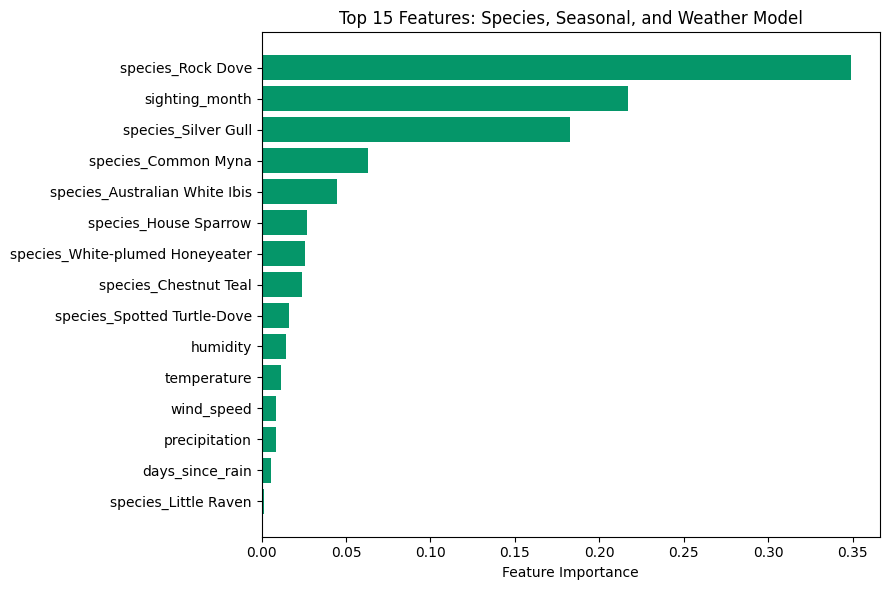

In [20]:
# Fit once on the full dataset (after cross validation above) purely to inspect which
# features the model relies on.
rf_model.fit(X_full, y_full)

importance_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending = False).head(15)

plt.figure(figsize = (9, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color = '#059669')
plt.xlabel('Feature Importance')
plt.title('Top 15 Features: Species, Seasonal, and Weather Model')
plt.tight_layout()
plt.show()

<div class="usecase-body"><b>Explanation:</b> The longest bars belong to individual species: Rock Dove and Silver Gull alone account for about 53% of the model's total feature importance, with sighting_month close behind at about 22%. All five weather variables combined, temperature, precipitation, humidity, wind speed, and days since rain, account for under 5% of the total. That lines up with the cross validation result just above: species identity and seasonal timing are doing nearly all of the work, while the weather features contribute comparatively little, even with two extra variables added to give them a fair chance.</div>

<div id="section-13" class="usecase-section-heading"><b>13. Predicting Sighting Counts per Species</b></div>

<div class="usecase-body">This cell intentionally reuses the weather only baseline model, rather than the species aware model above, to show what a weather only prediction looks like for each species. A model with no species information cannot distinguish between species, and the narrow predicted values below demonstrate exactly this. For each species, the model predicts a daily sighting count for every date on which weather data is available, and these predictions are averaged into a single representative value per species.</div>

In [21]:
### Predicting sighting count per species
# For each species, this uses the mean predicted count across all of that species' records,
# which is a more representative estimate than relying on any single record's prediction.

pred_sight = {}
for species in daily_species_df["common_name"].unique():
    species_data = daily_species_df[daily_species_df['common_name'] == species]
    X_spec = species_data[features]

    pred_si = model.predict(X_spec)
    pred_sight[species] = max(pred_si.mean(), 0)

pred_sight_df = (
    pd.DataFrame(pred_sight.items(), columns = ['common_name', 'predicted_sighting_count'])
    .sort_values('predicted_sighting_count', ascending = False)
    .reset_index(drop = True)
)
pred_sight_df['predicted_sighting_count'] = pred_sight_df['predicted_sighting_count'].round(2)

print(f"Predicted daily sighting count per species (weather-only baseline), sorted highest to "
      f"lowest, across all {len(pred_sight_df)} species:")
pred_sight_df

Predicted daily sighting count per species (weather-only baseline), sorted highest to lowest, across all 79 species:


,common_name,predicted_sighting_count
0,Darter,27.19
1,Hoary-headed Grebe,27.19
2,Musk Lorikeet,27.19
3,Eurasian Coot,27.19
4,Phylidonyris novaehollandiae,27.19
...,...,...
74,"Pacific Black Duck, Black Duck",0.91
75,Silvereye,0.00
76,Grey Fantail,0.00
77,Eastern Spinebill,0.00


<div class="usecase-body"><b>Explanation:</b> Because this model only accounts for weather and not species, its predicted values are very similar across almost every species. In the tested run, predictions ranged from 0.00 to 27.19 sightings across all 79 species, regardless of whether the species was common or rare. This narrow spread is itself the finding: a model with no species information cannot distinguish a Rock Dove, whose daily counts reach into the hundreds, from a species recorded only a handful of times in total.</div>

<div id="section-14" class="usecase-section-heading"><b>14. Comparing Actual vs Predicted Sightings</b></div>

<div class="usecase-body">The chart below compares each species' actual average daily sighting count with the model's predicted count, for the top 15 species by sighting count (showing every species at once made the axis unreadable). Actual and predicted bars are grouped side by side for each species so they can be compared directly.</div>

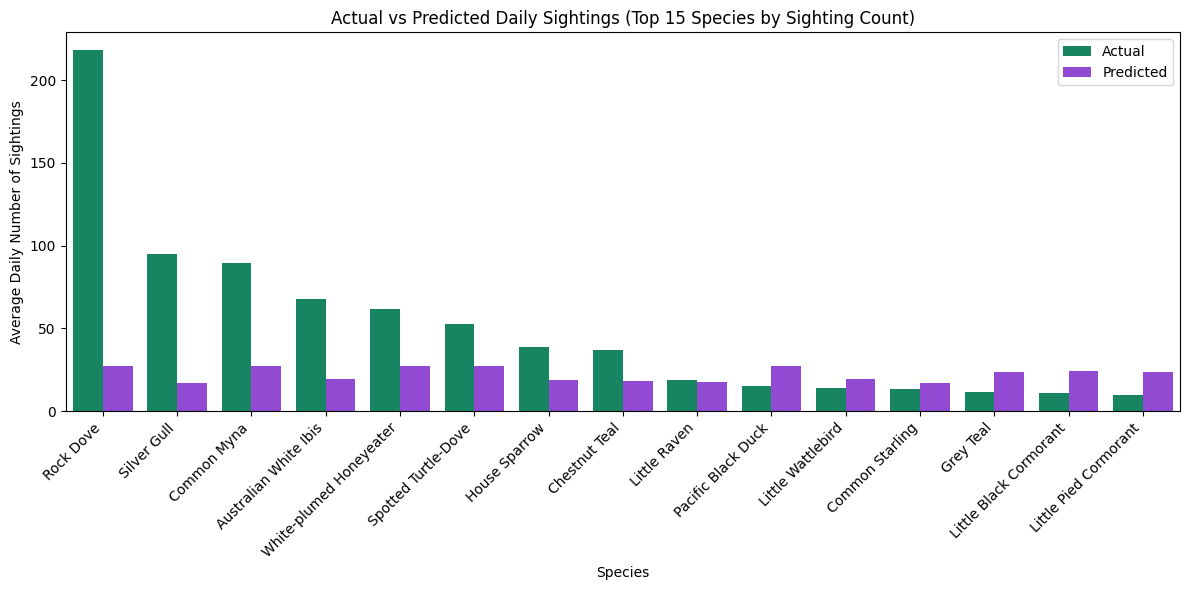

In [22]:
### Comparison of actual and predicted data

species_data = daily_species_df[['common_name', 'daily_sighting_count']].groupby('common_name', as_index = False).mean()
species_data['pred_si'] = [pred_sight[species] for species in species_data['common_name']]

# There are too many species to label legibly on one chart, so show the top N by actual
# average sighting count rather than every species crammed into an unreadable axis.
TOP_N = 15
top_species = species_data.sort_values('daily_sighting_count', ascending = False).head(TOP_N)

# Reshape to long form so actual vs. predicted render as properly grouped, side by side, bars.
plot_data = top_species.melt(
    id_vars = 'common_name',
    value_vars = ['daily_sighting_count', 'pred_si'],
    var_name = 'type',
    value_name = 'count'
)
plot_data['type'] = plot_data['type'].map({'daily_sighting_count': 'Actual', 'pred_si': 'Predicted'})

plt.figure(figsize = (12, 6))
sns.barplot(x = 'common_name', y = 'count', hue = 'type', data = plot_data,
            palette = {'Actual': '#059669', 'Predicted': '#9333EA'})  # approved template colours

plt.xlabel('Species')
plt.ylabel('Average Daily Number of Sightings')
plt.title(f'Actual vs Predicted Daily Sightings (Top {TOP_N} Species by Sighting Count)')
plt.xticks(rotation = 45, ha = 'right')
plt.legend(title = '')
plt.tight_layout()
plt.show()

<div class="usecase-body"><b>Explanation:</b> The green bars, representing actual daily sightings, vary considerably between species: Rock Dove, Silver Gull, and Common Myna were seen far more often per day than the rest in the tested run. The purple bars, representing predicted sightings, barely vary at all, remaining within a narrow band regardless of how common or rare the species is. This gap between widely varying actual counts and nearly identical predictions is the clearest visual evidence in the notebook that weather alone does not determine how many birds are recorded each day; species identity does.</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">Taken together, this analysis set out to answer the two questions posed in the Scenario: which bird species are seen around inner Melbourne rarely enough to warrant closer monitoring, and whether the weather on a given day helps explain how many birds are recorded. For the first question, Section 7's list of species recorded four times or fewer (32 of the 79 species identified) is a ready made starting point for prioritising closer monitoring. For the second question, the answer is no, not on its own: same day weather explains almost none of the variation in daily sighting counts, so weather forecasts are not a reliable basis for predicting bird activity or for scheduling monitoring visits. What does predict sighting counts far better is which species is being looked for and the time of year, so a council biodiversity officer or conservation researcher using this analysis is better served scheduling monitoring around species specific and seasonal patterns than around the day's forecast. Establishing this conclusion with real data, rather than assumption, is one of the most useful results in this notebook.</div>

<div class="usecase-body">

<b>What we achieved in this analysis</b>

<p>
We took two real Melbourne datasets, a structured 2018 bird survey and a broader 2014 "BioBlitz" citizen science dataset that recorded every type of wildlife, not just birds, and combined them into one clean, birds only dataset (279 of 670 BioBlitz records were confirmed to be birds; the remainder, including barnacles and trees, was correctly excluded). We mapped every sighting as both individual markers and a heatmap, identified species with few observation records, and paired every sighting with the real weather recorded on that exact date (776 sightings were successfully matched in the tested run). We then built and evaluated two prediction models: a weather only baseline covering temperature, precipitation, humidity, wind speed, and days since the last measurable rain, and an improved model that also considers species and time of year, tuned using a small cross validated hyperparameter search rather than a single fixed configuration.
</p>

<b>What we learned from this analysis</b>

<p>
Several clear patterns emerged directly from the data: a small number of species, including Rock Dove, Silver Gull, and Common Myna, account for a disproportionate share of sightings, while many others (32 of the 79 species identified) were recorded four times or fewer. Mapping the sightings also showed where activity concentrates across inner Melbourne, and the single busiest date (2018-02-15, 141 records) aligns with organised 2018 survey fieldwork rather than an unusual burst of bird activity. On the modelling side, the weather only baseline, now covering five weather variables instead of three, still explained almost none of the variation in daily sighting counts (R squared of 0.03), confirming what the correlation values in Section 10 already suggested: there is no meaningful direct relationship between same day weather and how many birds of a species are recorded. Adding species identity and season changed this picture substantially, and the hyperparameter search made that improvement far more dependable: the selected model explained roughly 41% of the variation in daily sighting counts with a fold to fold standard deviation of just 0.23, under half the variability of an unconstrained forest, though its average error (MAE of 13.24) was somewhat higher than an untuned model achieved on this particular split, a reasonable trade off for more consistent behaviour across folds. Section 14's chart makes the underlying reason visible: actual daily counts range from a handful of birds up to several hundred depending on the species, while a weather only model cannot distinguish between species at all.
</p>

<b>Observations for further opportunities</b>

<p>
weighting rarity by survey effort rather than raw counts is still unaddressed, since the data has no direct measure of how many times each location was surveyed; a count appropriate approach such as Poisson regression remains a more principled alternative to ordinary linear regression for this type of count data; and the bird only filter (class == 'AVES') should still be re checked against the live dataset each time this notebook runs, since these are open, evolving datasets whose structure can change over time.
</p>

</div>